#### Cryosat GOPM (LRM Geophysical Ocean Product) Level-2 altimetry data visualization.


In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import rasterio as rio 
import xarray as xr 


In [5]:
## cryosat-2 GOPM (LRM-GOP) data.
path_cryo2_gopm_l1b = 'data/cryosat-2/CS_OFFL_SIR_GOPM1B_20200908T022521_20200908T022633_C001.nc'  # GOPM:LRM-GOP
# path_cryo2_l2 = 'data/cryosat-2/l2/CS_OFFL_SIR_GOPM_2_20200908T022521_20200908T022633_C001.nc'  
## remote sensing data
path_rsimg = 'data/rsimg/dianchi_s2_20200511_wgs84.tif'


### Data reading

In [8]:
## 1. s3l2 altimetry data
# cryo2_l2 = nc.Dataset(path_cryo2_l2)   ##
cryo2_gopm_l1b = xr.open_dataset(path_cryo2_gopm_l1b)
## 2. remote sensing image
rsimg_rio = rio.open(path_rsimg)


In [9]:
cryo2_gopm_l1b


<xarray.Dataset>
Dimensions:                                 (time_01: 77, time_20_ku: 1295,
                                             ns_20_ku: 128, time_20_hr_ku: 0,
                                             space_3d: 3, ns_20_hr_ku: 0)
Coordinates:
    lat_01                                  (time_01) float64 ...
    lat_20_ku                               (time_20_ku) float64 ...
    lon_01                                  (time_01) float64 ...
    lon_20_ku                               (time_20_ku) float64 ...
  * ns_20_ku                                (ns_20_ku) int16 0 1 2 ... 126 127
  * time_01                                 (time_01) datetime64[ns] 2020-09-...
  * time_20_ku                              (time_20_ku) datetime64[ns] 2020-...
  * ns_20_hr_ku                             (ns_20_hr_ku) float32 
  * time_20_hr_ku                           (time_20_hr_ku) datetime64[ns] 
Dimensions without coordinates: space_3d
Data variables: (12/116)
    agc_01_ku                               (time_01) float32 ...
    agc_20_ku                               (time_20_ku) float32 ...
    agc_cor_01                              (time_01) float32 ...
    alt_01                                  (time_01) float64 ...
    alt_20_ku                               (time_20_ku) float64 ...
    cog_cor_01                              (time_01) float32 ...
    ...                                      ...
    stack_std_angle_20_hr_ku                (time_20_hr_ku) float32 ...
    tot_gain_ch1_20_hr_ku                   (time_20_hr_ku) float64 ...
    tot_gain_ch2_20_hr_ku                   (time_20_hr_ku) float64 ...
    transmit_pwr_20_hr_ku                   (time_20_hr_ku) float64 ...
    uso_cor_20_hr_ku                        (time_20_hr_ku) float64 ...
    window_del_20_hr_ku                     (time_20_hr_ku) timedelta64[ns] ...
Attributes: (12/81)
    product_name:                 CS_OFFL_SIR_GOPM1B_20200908T022521_20200908...
    processing_stage:             OFFL
    reference_document:           C2-RS-ACS-ESL-5266 3.4 
    acquisition_station:          Kiruna              
    mission:                      Cryosat
    processing_centre:            PDS
    ...                           ...
    xref_surf_type:               4-states Land Sea Mask
    xref_tidal_load_sol1:         GOT4.10c
    xref_tidal_load_sol2:         FES2014b
    xref_u_wind:                  CS_OPER_AUX_U_WIND_20200908T000000_20200908...
    xref_v_wind:                  CS_OPER_AUX_V_WIND_20200908T000000_20200908...
    xref_wet_trop:                CS_OPER_AUX_WETTRP_20200908T000000_20200908...

In [10]:
print('Cryosat-1 l1b data:')
for i in range(len(cryo2_gopm_l1b.variables.keys())):
    print(list(cryo2_gopm_l1b.variables.keys())[i])


Cryosat-1 l1b data:
agc_01_ku
agc_20_ku
agc_cor_01
alt_01
alt_20_ku
cog_cor_01
cor2_applied_20_ku
dop_cor_01_ku
dop_cor_20_ku
echo_numval_20_ku
echo_scale_20_ku
flag_cor_err_01
flag_cor_status_01
flag_instr_conf_rx_bwdt_20_ku
flag_instr_conf_rx_flags_20_ku
flag_instr_conf_rx_in_use_20_ku
flag_instr_conf_rx_trk_mode_20_ku
flag_instr_op_mode_20_ku
flag_mcd_20_ku
flag_trk_cycle_20_ku
h0_applied_20_ku
h0_fai_word_20_ku
h0_lai_word_20_ku
hf_fluct_cor_01
ind_first_meas_20hz_01
ind_meas_1hz_20_ku
int_path_cor_01
internal_cor_sig0_01
inv_bar_cor_01
iono_cor_gim_01
lat_01
lat_20_ku
load_tide_sol1_01
load_tide_sol2_01
lon_01
lon_20_ku
mod_dry_tropo_cor_01
mod_wet_tropo_cor_01
noise_power_20_ku
ns_20_ku
num_meas_20hz_01
ocean_tide_eq_01
ocean_tide_non_eq_01
ocean_tide_sol1_01
ocean_tide_sol2_01
orb_alt_rate_01
orb_alt_rate_20_ku
pole_tide_01
pwr_waveform_20_ku
rec_count_20_ku
scale_factor_20_ku
seq_count_20_ku
solid_earth_tide_01
surf_type_01
time_01
time_20_ku
tracker_range_20_ku
uso_cor_01_ku
u

In [11]:
lon_20_ku_l1b = cryo2_gopm_l1b['lon_20_ku'][:]
lat_20_ku_l1b = cryo2_gopm_l1b['lat_20_ku'][:]
time_20_ku_l1b = cryo2_gopm_l1b['time_20_ku'][:]
waveform_l1b = cryo2_gopm_l1b['pwr_waveform_20_ku'][:]
print(waveform_l1b.shape)  ## waveform


(1295, 128)


In [7]:
# print('Cryosat-2 l2 data:')
# for i in range(len(cryo2_l2.variables.keys())):
#     print(list(cryo2_l2.variables.keys())[i])


In [8]:
# lon_20_ku_l2 = cryo2_l2['lon_20_ku'][:]
# lat_20_ku_l2 = cryo2_l2['lat_20_ku'][:]
# time_20_ku_l2 = cryo2_l2['time_20_ku'][:]
# time_20_ku_dyr_l2 = second_to_dyr(time_20_ku_l2)
# print(time_20_ku_l2.shape)  ## 


### Visualization from global perspective

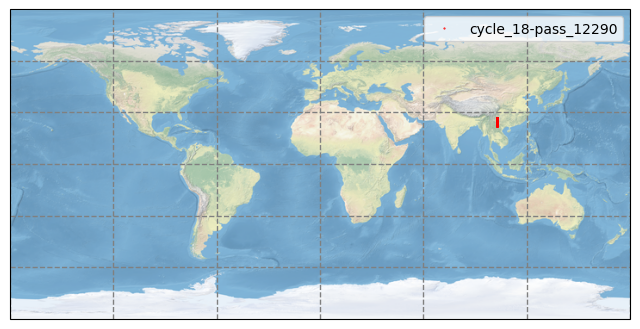

In [12]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection=proj)
ax.stock_img()
orbit = 'cycle_'+str(cryo2_gopm_l1b.cycle_number)+'-pass_'+str(cryo2_gopm_l1b.rel_orbit_number)
ax.plot(cryo2_gopm_l1b['lon_20_ku'][:], cryo2_gopm_l1b['lat_20_ku'][:], marker='.', markersize=1, 
                                                        linewidth=0.0, label=orbit, color='red')
ax.gridlines(linewidth=1, color='gray', linestyle='--')
ax.legend()


### Visualization from local perspective

In [15]:
rsimg_color = rsimg_rio.read()[0:3,:,:].transpose(1,2,0)[:,:,::-1]
rsimg_color = (rsimg_color - 0) / (2500)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..6.68].


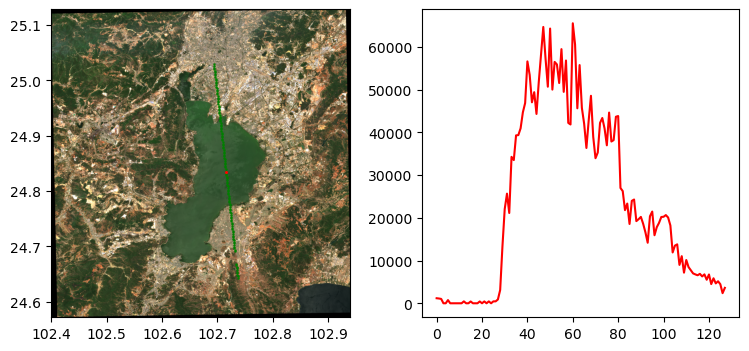

In [16]:
ids = np.where((lat_20_ku_l1b[:]>24.64) & (lat_20_ku_l1b[:]<25.03))[0]  
id = ids[60]
fig, ax = plt.subplots(1,2,figsize=(9,4))
ax[0].imshow(rsimg_color, extent=(rsimg_rio.bounds.left, 
                                rsimg_rio.bounds.right, 
                                rsimg_rio.bounds.bottom, 
                                rsimg_rio.bounds.top))
ax[0].scatter(x=lon_20_ku_l1b[ids], y=lat_20_ku_l1b[ids], s=0.5, color='green')  ## altimetry data
ax[0].scatter(x=lon_20_ku_l1b[id], y=lat_20_ku_l1b[id], s=1.5, color='red')  ## altimetry data
ax[1].plot(waveform_l1b[id], color='red')
